# Week 4 Major Project: Heart Disease Prediction

## Objective

Build a machine learning model to predict whether a patient is likely to have heart disease.

### Workflow
1. Load and inspect the dataset
2. Clean the data
3. Prepare features and target
4. Scale the features
5. Train a classification model
6. Evaluate accuracy, precision, and recall
7. Create a confusion matrix
8. Create an ROC curve

In [131]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [132]:
data = pd.read_csv("heart_disease_uci.csv")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [133]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None


In [134]:
print(data.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [135]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [136]:
print("Target values:")
print(data["num"].value_counts().sort_index())

Target values:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [137]:
data["target"] = (data["num"] > 0).astype(int)

print("Target distribution:")
print(data["target"].value_counts())

Target distribution:
target
1    509
0    411
Name: count, dtype: int64


In [138]:
data = data.drop(columns=["id", "dataset", "num"])

print("Columns after removing unnecessary columns:")
print(data.columns.tolist())

Columns after removing unnecessary columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [139]:
print(data.dtypes)

age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
target        int64
dtype: object


In [140]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

for column in numerical_columns:
    data[column] = data[column].fillna(data[column].median())

for column in categorical_columns:
    data[column] = data[column].fillna(data[column].mode()[0])

print("Remaining missing values:")
print(data.isnull().sum())

Remaining missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


C:\temp\ipykernel_16452\3670857303.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[column] = data[column].fillna(data[column].mode()[0])


In [141]:
data = pd.get_dummies(
    data,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Dataset shape after encoding:", data.shape)
print(data.head())

Dataset shape after encoding: (920, 19)
   age  trestbps   chol  thalch  oldpeak   ca  target  sex_Male  \
0   63     145.0  233.0   150.0      2.3  0.0       0         1   
1   67     160.0  286.0   108.0      1.5  3.0       1         1   
2   67     120.0  229.0   129.0      2.6  2.0       1         1   
3   37     130.0  250.0   187.0      3.5  0.0       0         1   
4   41     130.0  204.0   172.0      1.4  0.0       0         0   

   cp_atypical angina  cp_non-anginal  cp_typical angina  fbs_True  \
0                   0               0                  1         1   
1                   0               0                  0         0   
2                   0               0                  0         0   
3                   0               1                  0         0   
4                   1               0                  0         0   

   restecg_normal  restecg_st-t abnormality  exang_True  slope_flat  \
0               0                         0           0          

In [142]:
X = data.drop("target", axis=1)
y = data["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (920, 18)
Target shape: (920,)


In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (736, 18)
Testing data: (184, 18)


In [144]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (736, 18)
Scaled testing data: (184, 18)


In [145]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [146]:
y_pred = model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 1 1 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 1 1 1 1
 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 0 1
 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1
 0 0 1 1 1 1 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 1 1 1 0
 0 1 1 0 1 1 1 1 0 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1]


In [147]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.842391304347826
Precision: 0.8411214953271028
Recall: 0.8823529411764706


In [148]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[65 17]
 [12 90]]


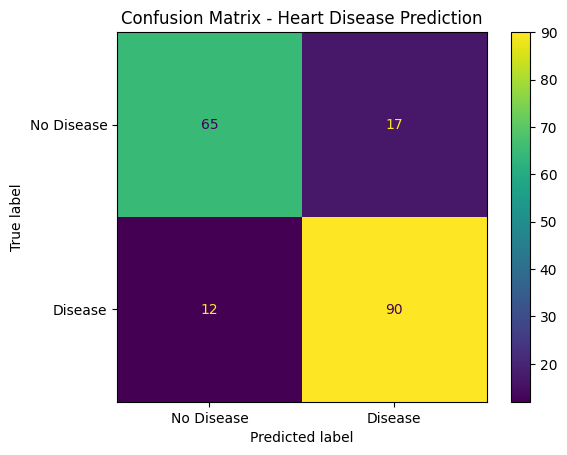

In [149]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Confusion Matrix - Heart Disease Prediction")
plt.show()

In [150]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9031563845050216


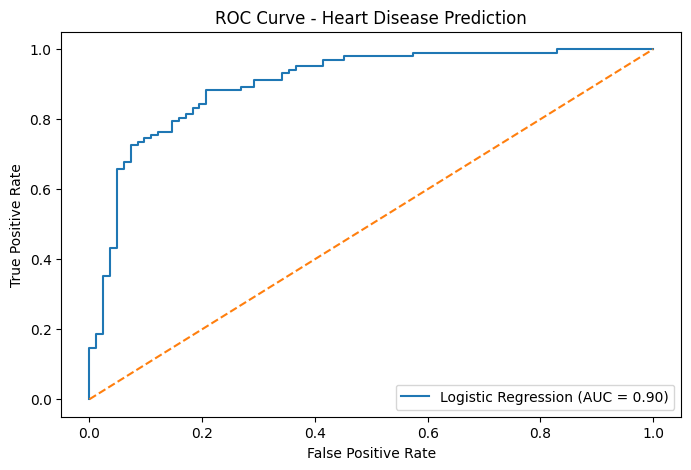

In [151]:
plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Disease Prediction")
plt.legend()

plt.show()

In [152]:
import joblib

joblib.dump(model, "heart_disease_model.pkl")
joblib.dump(scaler, "heart_disease_scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [153]:
loaded_model = joblib.load("heart_disease_model.pkl")
loaded_scaler = joblib.load("heart_disease_scaler.pkl")

print("Model and scaler loaded successfully.")

Model and scaler loaded successfully.


In [154]:
new_patient = X_test.iloc[[0]]

new_patient_scaled = loaded_scaler.transform(new_patient)

prediction = loaded_model.predict(new_patient_scaled)

print("Predicted class:", prediction[0])

if prediction[0] == 1:
    print("Prediction: Heart disease likely")
else:
    print("Prediction: No heart disease likely")

Predicted class: 0
Prediction: No heart disease likely


## Final Project Summary

A Heart Disease Prediction model was developed using Logistic Regression.

### Results

- Dataset: 920 rows and 16 columns
- Training data: 736 samples
- Testing data: 184 samples
- Features after preprocessing: 18
- Accuracy: 84.24%
- Precision: 84.11%
- Recall: 88.24%
- ROC-AUC: 0.90

The model was evaluated using accuracy, precision, recall, a confusion matrix, and an ROC curve.

The trained Logistic Regression model and StandardScaler were saved using joblib and successfully loaded again for prediction on new data.